# Task 1 – Data Import & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_excel(r'D:\class\python\assignments\module_2\Online Retail.xlsx')

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [6]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

#  Task 2 – Data Cleaning

In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df.shape

(541909, 8)

In [9]:
df=df.dropna(subset=['CustomerID'])

In [10]:
df.shape

(406829, 8)

In [11]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(5225)

In [13]:
df=df.drop_duplicates()

In [14]:
df.shape

(401604, 8)

In [15]:
# Fixing invalid values by removing them
df=df[df['Quantity'] >= 0]

In [16]:
df.shape

(392732, 8)

In [17]:
# Fixing invalid values by removing them
df=df[df['UnitPrice']>0]

In [18]:
df.shape

(392692, 8)

# Task 3 – Feature Engineering

In [19]:
df['TotalPrice']=df['Quantity'] * df['UnitPrice']

In [20]:
df[['Quantity','UnitPrice','TotalPrice']].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [21]:
df['Year']=df['InvoiceDate'].dt.year
df['Month']=df['InvoiceDate'].dt.month
df['Day']=df['InvoiceDate'].dt.day
df['Hour']=df['InvoiceDate'].dt.hour

In [22]:
# Customer segmentation
df.loc[(df['Quantity'] >= 0) & (df['Quantity'] <= 25000), 'Customer_segment'] = 'Verylow'
df.loc[(df['TotalPrice'] > 25000) & (df['TotalPrice'] <= 50000), 'Customer_segment'] = 'Low'
df.loc[(df['TotalPrice'] > 50000) & (df['TotalPrice'] <= 75000), 'Customer_segment'] = 'Medium'
df.loc[(df['TotalPrice'] > 75000) & (df['TotalPrice'] <= 100000), 'Customer_segment'] = 'High'
df.loc[df['TotalPrice'] > 100000, 'Customer_segment'] = 'Veryhigh'

In [23]:
# Order type
df.loc[(df['Quantity'] >= 0) & (df['Quantity'] <= 1000), 'Order_Type'] = 'Small'
df.loc[(df['Quantity'] > 1000) & (df['Quantity'] <= 2000), 'Order_Type'] = 'Medium'
df.loc[(df['Quantity'] > 2000) & (df['Quantity'] <= 3000), 'Order_Type'] = 'Large'
df.loc[df['Quantity'] > 3000, 'Order_Type'] = 'Bulk'

In [24]:
# Day type
df['Day_Type']=df['InvoiceDate'].dt.dayofweek.apply(lambda x: 'Weekend' if x>=5 else 'Weekday')

# Task 4 – Data Exploration

In [25]:
df.describe(include=['number'])

,Quantity,UnitPrice,CustomerID,TotalPrice,Year,Month,Day,Hour
count,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,15287.843865,22.631500,2010.934631,7.601871,15.044656,12.721532
std,180.492832,22.241836,1713.539549,311.099224,0.247177,3.415015,8.652532,2.276661
min,1.000000,0.001000,12346.000000,0.001000,2010.000000,1.000000,1.000000,6.000000
25%,2.000000,1.250000,13955.000000,4.950000,2011.000000,5.000000,7.000000,11.000000
50%,6.000000,1.950000,15150.000000,12.450000,2011.000000,8.000000,15.000000,13.000000
75%,12.000000,3.750000,16791.000000,19.800000,2011.000000,11.000000,22.000000,14.000000
max,80995.000000,8142.750000,18287.000000,168469.600000,2011.000000,12.000000,31.000000,20.000000


In [26]:
df.describe(include=['object'])

,InvoiceNo,StockCode,Description,Country,Customer_segment,Order_Type,Day_Type
count,392692,392692,392692,392692,392692,392692,392692
unique,18532,3665,3877,37,4,4,2
top,576339,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom,Verylow,Small,Weekday
freq,542,2023,2016,349203,392689,392588,331480


In [27]:
cat_col=df.select_dtypes(include=['object','category'])
for col in cat_col.columns[3:]:
    print(f'value counts of "{col}"')
    print(df[col].value_counts())
    print()
    print(f'unique values of "{col}"')
    print(df[col].unique())
    print()

value counts of "Country"
Country
United Kingdom          349203
Germany                   9025
France                    8326
EIRE                      7226
Spain                     2479
Netherlands               2359
Belgium                   2031
Switzerland               1841
Portugal                  1453
Australia                 1181
Norway                    1071
Italy                      758
Channel Islands            747
Finland                    685
Cyprus                     603
Sweden                     450
Austria                    398
Denmark                    380
Poland                     330
Japan                      321
Israel                     245
Unspecified                241
Singapore                  222
Iceland                    182
USA                        179
Canada                     151
Greece                     145
Malta                      112
United Arab Emirates        68
European Community          60
RSA                         57
Leban

In [28]:
df.groupby(['Country','Month','Description']).first()

InvoiceNo StockCode  \
Country     Month Description                                              
Australia   1     3 HOOK HANGER MAGIC GARDEN            540700     22244   
                  4 TRADITIONAL SPINNING TOPS           540267     22620   
                  6 RIBBONS RUSTIC CHARM                540267     22077   
                  ALARM CLOCK BAKELIKE GREEN            542542     22726   
                  ALARM CLOCK BAKELIKE IVORY            542542     22730   
...                                                        ...       ...   
Unspecified 8     ROUND CAKE TIN VINTAGE RED            564051     22840   
                  SET OF 72 RETROSPOT PAPER  DOILIES    563947     21210   
                  STORAGE TIN VINTAGE DOILY             563947     23236   
                  VINTAGE CHRISTMAS BUNTING             563947     23313   
                  VINTAGE CREAM CAT FOOD CONTAINER      564051     22845   

                                                      Quantity  \
Country     Month Description                                    
Australia   1     3 HOOK HANGER MAGIC GARDEN                12   
                  4 TRADITIONAL SPINNING TOPS              160   
                  6 RIBBONS RUSTIC CHARM                   144   
                  ALARM CLOCK BAKELIKE GREEN                 4   
                  ALARM CLOCK BAKELIKE IVORY                 4   
...                                                        ...   
Unspecified 8     ROUND CAKE TIN VINTAGE RED                 2   
                  SET OF 72 RETROSPOT PAPER  DOILIES        12   
                  STORAGE TIN VINTAGE DOILY                 24   
                  VINTAGE CHRISTMAS BUNTING                  6   
                  VINTAGE CREAM CAT FOOD CONTAINER           4   

                                                             InvoiceDate  \
Country     Month Description                                              
Australia   1     3 HOOK HANGER MAGIC GARDEN         2011-01-11 09:47:00   
                  4 TRADITIONAL SPINNING TOPS        2011-01-06 11:12:00   
                  6 RIBBONS RUSTIC CHARM             2011-01-06 11:12:00   
                  ALARM CLOCK BAKELIKE GREEN         2011-01-28 14:37:00   
                  ALARM CLOCK BAKELIKE IVORY         2011-01-28 14:37:00   
...                                                                  ...   
Unspecified 8     ROUND CAKE TIN VINTAGE RED         2011-08-22 13:32:00   
                  SET OF 72 RETROSPOT PAPER  DOILIES 2011-08-22 10:18:00   
                  STORAGE TIN VINTAGE DOILY          2011-08-22 10:18:00   
                  VINTAGE CHRISTMAS BUNTING          2011-08-22 10:18:00   
                  VINTAGE CREAM CAT FOOD CONTAINER   2011-08-22 13:32:00   

                                                      UnitPrice  CustomerID  \
Country     Month Description                                                 
Australia   1     3 HOOK HANGER MAGIC GARDEN               1.95     12393.0   
                  4 TRADITIONAL SPINNING TOPS              1.06     12415.0   
                  6 RIBBONS RUSTIC CHARM                   1.45     12415.0   
                  ALARM CLOCK BAKELIKE GREEN               3.75     12431.0   
                  ALARM CLOCK BAKELIKE IVORY               3.75     12431.0   
...                                                         ...         ...   
Unspecified 8     ROUND CAKE TIN VINTAGE RED               7.95     14265.0   
                  SET OF 72 RETROSPOT PAPER  DOILIES       1.45     12363.0   
                  STORAGE TIN VINTAGE DOILY                2.89     12363.0   
                  VINTAGE CHRISTMAS BUNTING                4.95     12363.0   
                  VINTAGE CREAM CAT FOOD CONTAINER         6.35     14265.0   

                                                      TotalPrice  Year  Day  \
Country     Month Description                                                 
Australia   1     3 HOOK HANGE

# Task 5 – Data Wrangling

In [29]:
df['CustomerID'].unique().sum()

np.float64(66373170.0)

In [30]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,Hour,Customer_segment,Order_Type,Day_Type
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,8,Verylow,Small,Weekday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Verylow,Small,Weekday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,8,Verylow,Small,Weekday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Verylow,Small,Weekday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Verylow,Small,Weekday


In [31]:
df.groupby(['Month','Year','Description','UnitPrice'])['UnitPrice'].agg(['sum','mean','count']).reset_index().head(10)


,Month,Year,Description,UnitPrice,sum,mean,count
0,1,2011,4 PURPLE FLOCK DINNER CANDLES,2.55,5.10,2.55,2
1,1,2011,OVAL WALL MIRROR DIAMANTE,9.95,59.70,9.95,6
2,1,2011,SET 2 TEA TOWELS I LOVE LONDON,2.55,5.10,2.55,2
3,1,2011,SET 2 TEA TOWELS I LOVE LONDON,2.95,61.95,2.95,21
4,1,2011,10 COLOUR SPACEBOY PEN,0.85,11.05,0.85,13
5,1,2011,12 COLOURED PARTY BALLOONS,0.65,3.90,0.65,6
6,1,2011,12 DAISY PEGS IN WOOD BOX,1.65,21.45,1.65,13
7,1,2011,12 EGG HOUSE PAINTED WOOD,12.75,76.50,12.75,6
8,1,2011,12 IVORY ROSE PEG PLACE SETTINGS,1.25,11.25,1.25,9
9,1,2011,12 MESSAGE CARDS WITH ENVELOPES,1.65,16.50,1.65,10


In [32]:
a=df.groupby(['Year','Customer_segment','Order_Type','Day_Type'])['Quantity'].agg('sum').reset_index()
a

,Year,Customer_segment,Order_Type,Day_Type,Quantity
0,2010,Verylow,Large,Weekday,5280
1,2010,Verylow,Medium,Weekday,10858
2,2010,Verylow,Medium,Weekend,1728
3,2010,Verylow,Small,Weekday,264462
4,2010,Verylow,Small,Weekend,28720
5,2011,High,Bulk,Weekday,74215
6,2011,Low,Small,Weekday,60
7,2011,Veryhigh,Bulk,Weekday,80995
8,2011,Verylow,Bulk,Weekday,22420
9,2011,Verylow,Large,Weekday,22512


In [33]:
top5_customer=df.groupby('CustomerID')['TotalPrice'].sum().reset_index().sort_values(by='TotalPrice', ascending=False)[:5]
top5_customer

,CustomerID,TotalPrice
1689,14646.0,280206.02
4201,18102.0,259657.30
3728,17450.0,194390.79
3008,16446.0,168472.50
1879,14911.0,143711.17


In [34]:
top5_Country=df.groupby('Country')['TotalPrice'].sum().reset_index().sort_values(by='TotalPrice', ascending=False)[:5]
top5_Country

,Country,TotalPrice
35,United Kingdom,7285024.644
23,Netherlands,285446.340
10,EIRE,265262.460
14,Germany,228678.400
13,France,208934.310


#  Task 6 – Statistical Analysis

In [35]:
cols=['Quantity','UnitPrice','TotalPrice']
for col in cols:
    print(f'Mean   of "{col}"       = {df[col].mean()}')
    print(f'Median of "{col}"       = {df[col].median()}')
    print(f'Mode   of "{col}"       = {df[col].mode()[0]}')
    print(f'Standard Deviation of "{col}" = {df[col].std()}')
    print(f'Variance    of "{col}"  = {df[col].var()}')
    print(f'Quantile of "{col}"  = \n{df[col].quantile([0.25,0.5,0.75])}')
    print(f'Percentiles of "{col}"  = {np.percentile(df[col], 90)}')
    print()

Mean   of "Quantity"       = 13.1197019547126
Median of "Quantity"       = 6.0
Mode   of "Quantity"       = 1
Standard Deviation of "Quantity" = 180.49283198902435
Variance    of "Quantity"  = 32577.662399418172
Quantile of "Quantity"  = 
0.25     2.0
0.50     6.0
0.75    12.0
Name: Quantity, dtype: float64
Percentiles of "Quantity"  = 24.0

Mean   of "UnitPrice"       = 3.1259139070823956
Median of "UnitPrice"       = 1.95
Mode   of "UnitPrice"       = 1.25
Standard Deviation of "UnitPrice" = 22.2418356140519
Variance    of "UnitPrice"  = 494.6992514825076
Quantile of "UnitPrice"  = 
0.25    1.25
0.50    1.95
0.75    3.75
Name: UnitPrice, dtype: float64
Percentiles of "UnitPrice"  = 6.35

Mean   of "TotalPrice"       = 22.631499735161402
Median of "TotalPrice"       = 12.45
Mode   of "TotalPrice"       = 15.0
Standard Deviation of "TotalPrice" = 311.09922433480364
Variance    of "TotalPrice"  = 96782.72738171647
Quantile of "TotalPrice"  = 
0.25     4.95
0.50    12.45
0.75    19.80
Na

# Task 7 – Data Visualization

### Matplotlib:

In [36]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()
monthly_sales

Month
1      568101.310
2      446084.920
3      594081.760
4      468374.331
5      677355.150
6      660046.050
7      598962.901
8      644051.040
9      950690.202
10    1035642.450
11    1156205.610
12    1087613.170
Name: TotalPrice, dtype: float64

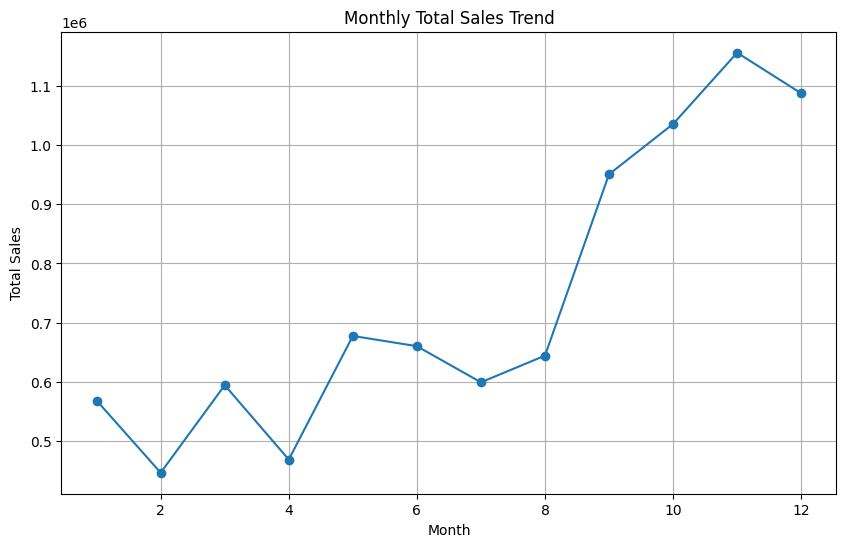

In [37]:
plt.figure(figsize=(10,6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Total Sales Trend')
plt.grid(True)
plt.show()


### The lineplot shows the growth of the sales from 2nd month to 12th month. Sales was gone good, but last one month the growth was down way. It wa not good at the end of the year. It should be show good growth, why means, it was the year end, there were lot of offers given.

In [38]:
day_total=df.groupby('Day_Type')['TotalPrice'].sum()
day_total

Day_Type
Weekday    8101718.573
Weekend     785490.321
Name: TotalPrice, dtype: float64

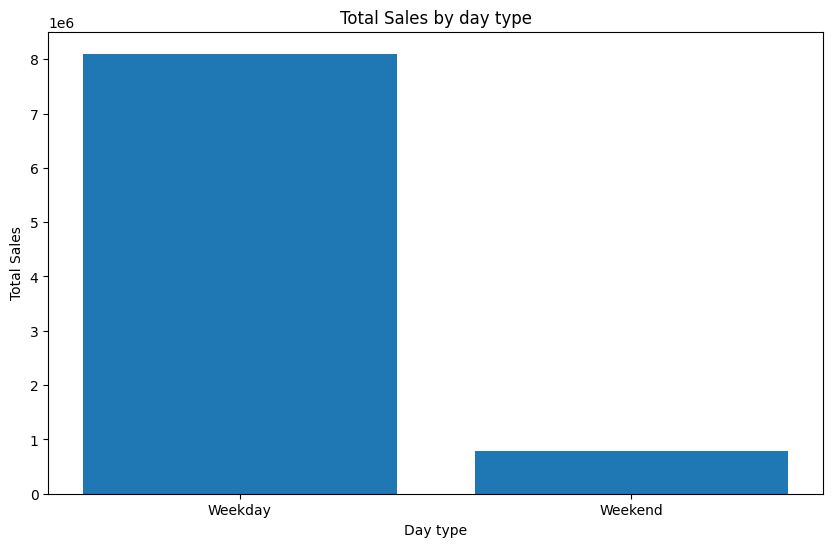

In [39]:
plt.figure(figsize=(10,6))
plt.bar(x=day_total.index, height=day_total.values)
plt.xlabel('Day type')
plt.ylabel('Total Sales')
plt.title('Total Sales by day type')
plt.show()

### The bar plot shows that weekdays has more sales than the weekend. So, the people are likely to the products on weekdays

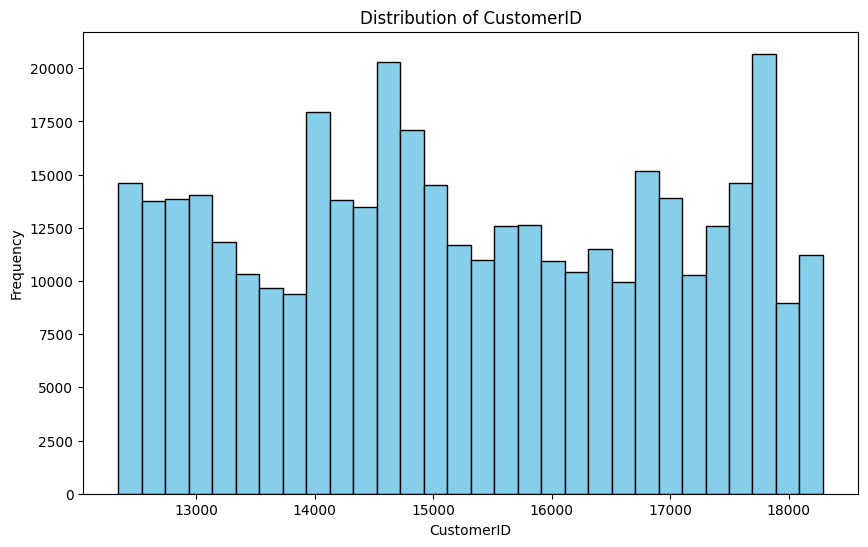

In [40]:
plt.figure(figsize=(10,6))
plt.hist(df['CustomerID'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('CustomerID')
plt.ylabel('Frequency')
plt.title('Distribution of CustomerID')
plt.show()


### The Histogram ploy shows the distribution of customer id. We can observe the range of customer brought the products

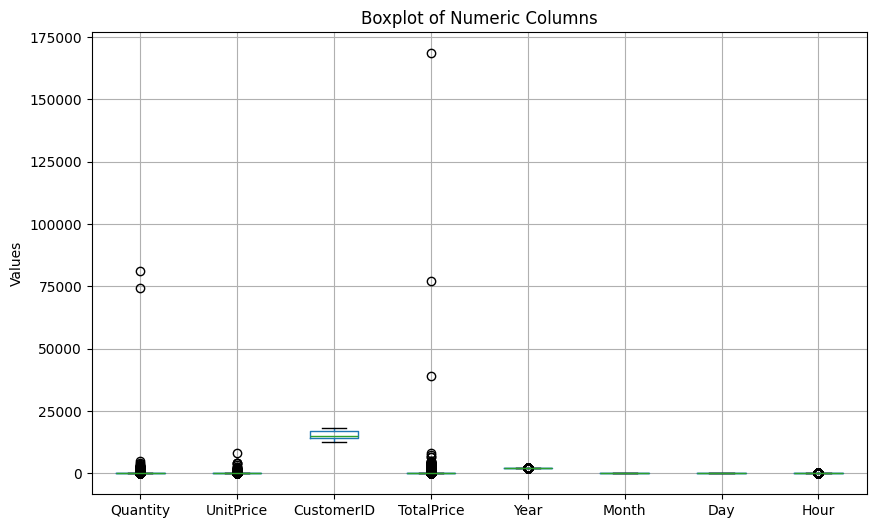

In [41]:
plt.figure(figsize=(10,6))
df.boxplot()
plt.title("Boxplot of Numeric Columns")
plt.ylabel("Values")
plt.show()

### Most of the transactions are small, but Quantity and TotalPrice show some very large values, meaning a few bulk or high‑value orders stand out. UnitPrice is mostly low, with only a handful of expensive items pushing the range higher. CustomerID spreads widely but doesn’t really add insight since it’s just an identifier.

## Seaborn:

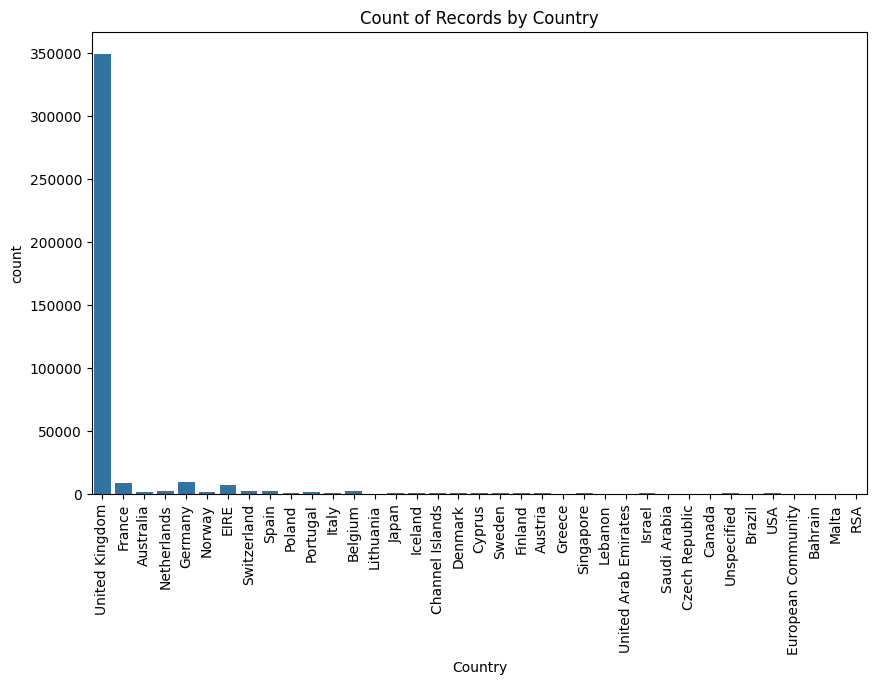

In [42]:
plt.figure(figsize=(10,6))
sns.countplot(x='Country', data=df)
plt.title("Count of Records by Country")
plt.xticks(rotation=90)
plt.show()

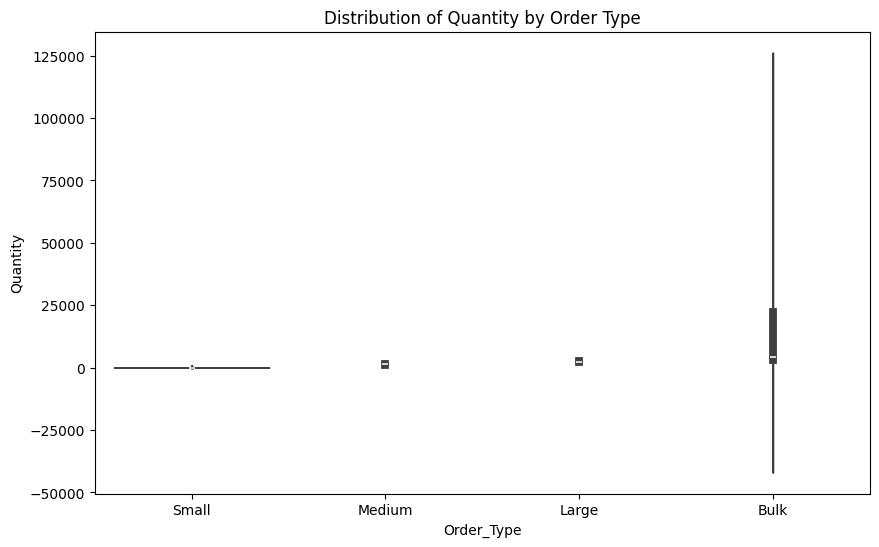

In [43]:
plt.figure(figsize=(10,6))
sns.violinplot(x='Order_Type', y='Quantity', data=df)
plt.title("Distribution of Quantity by Order Type")
plt.show()

In [44]:
num_col=df.select_dtypes(include='number')
corr=num_col.corr()

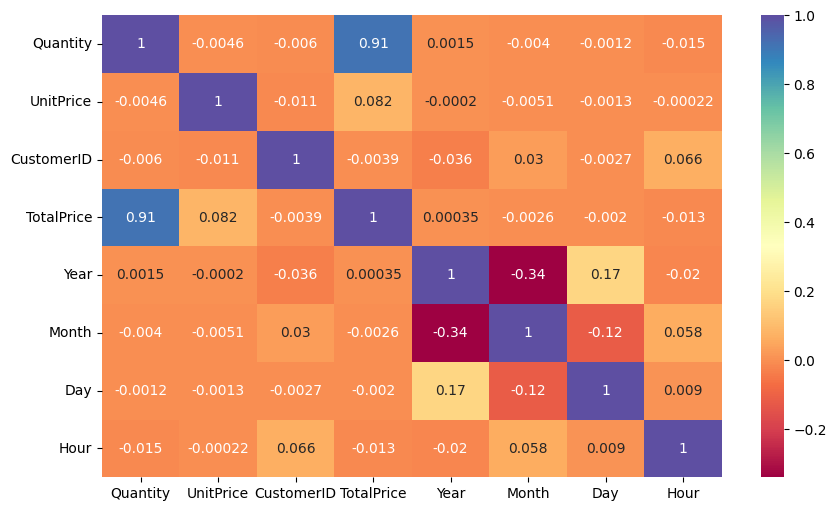

In [45]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='Spectral')
plt.show()

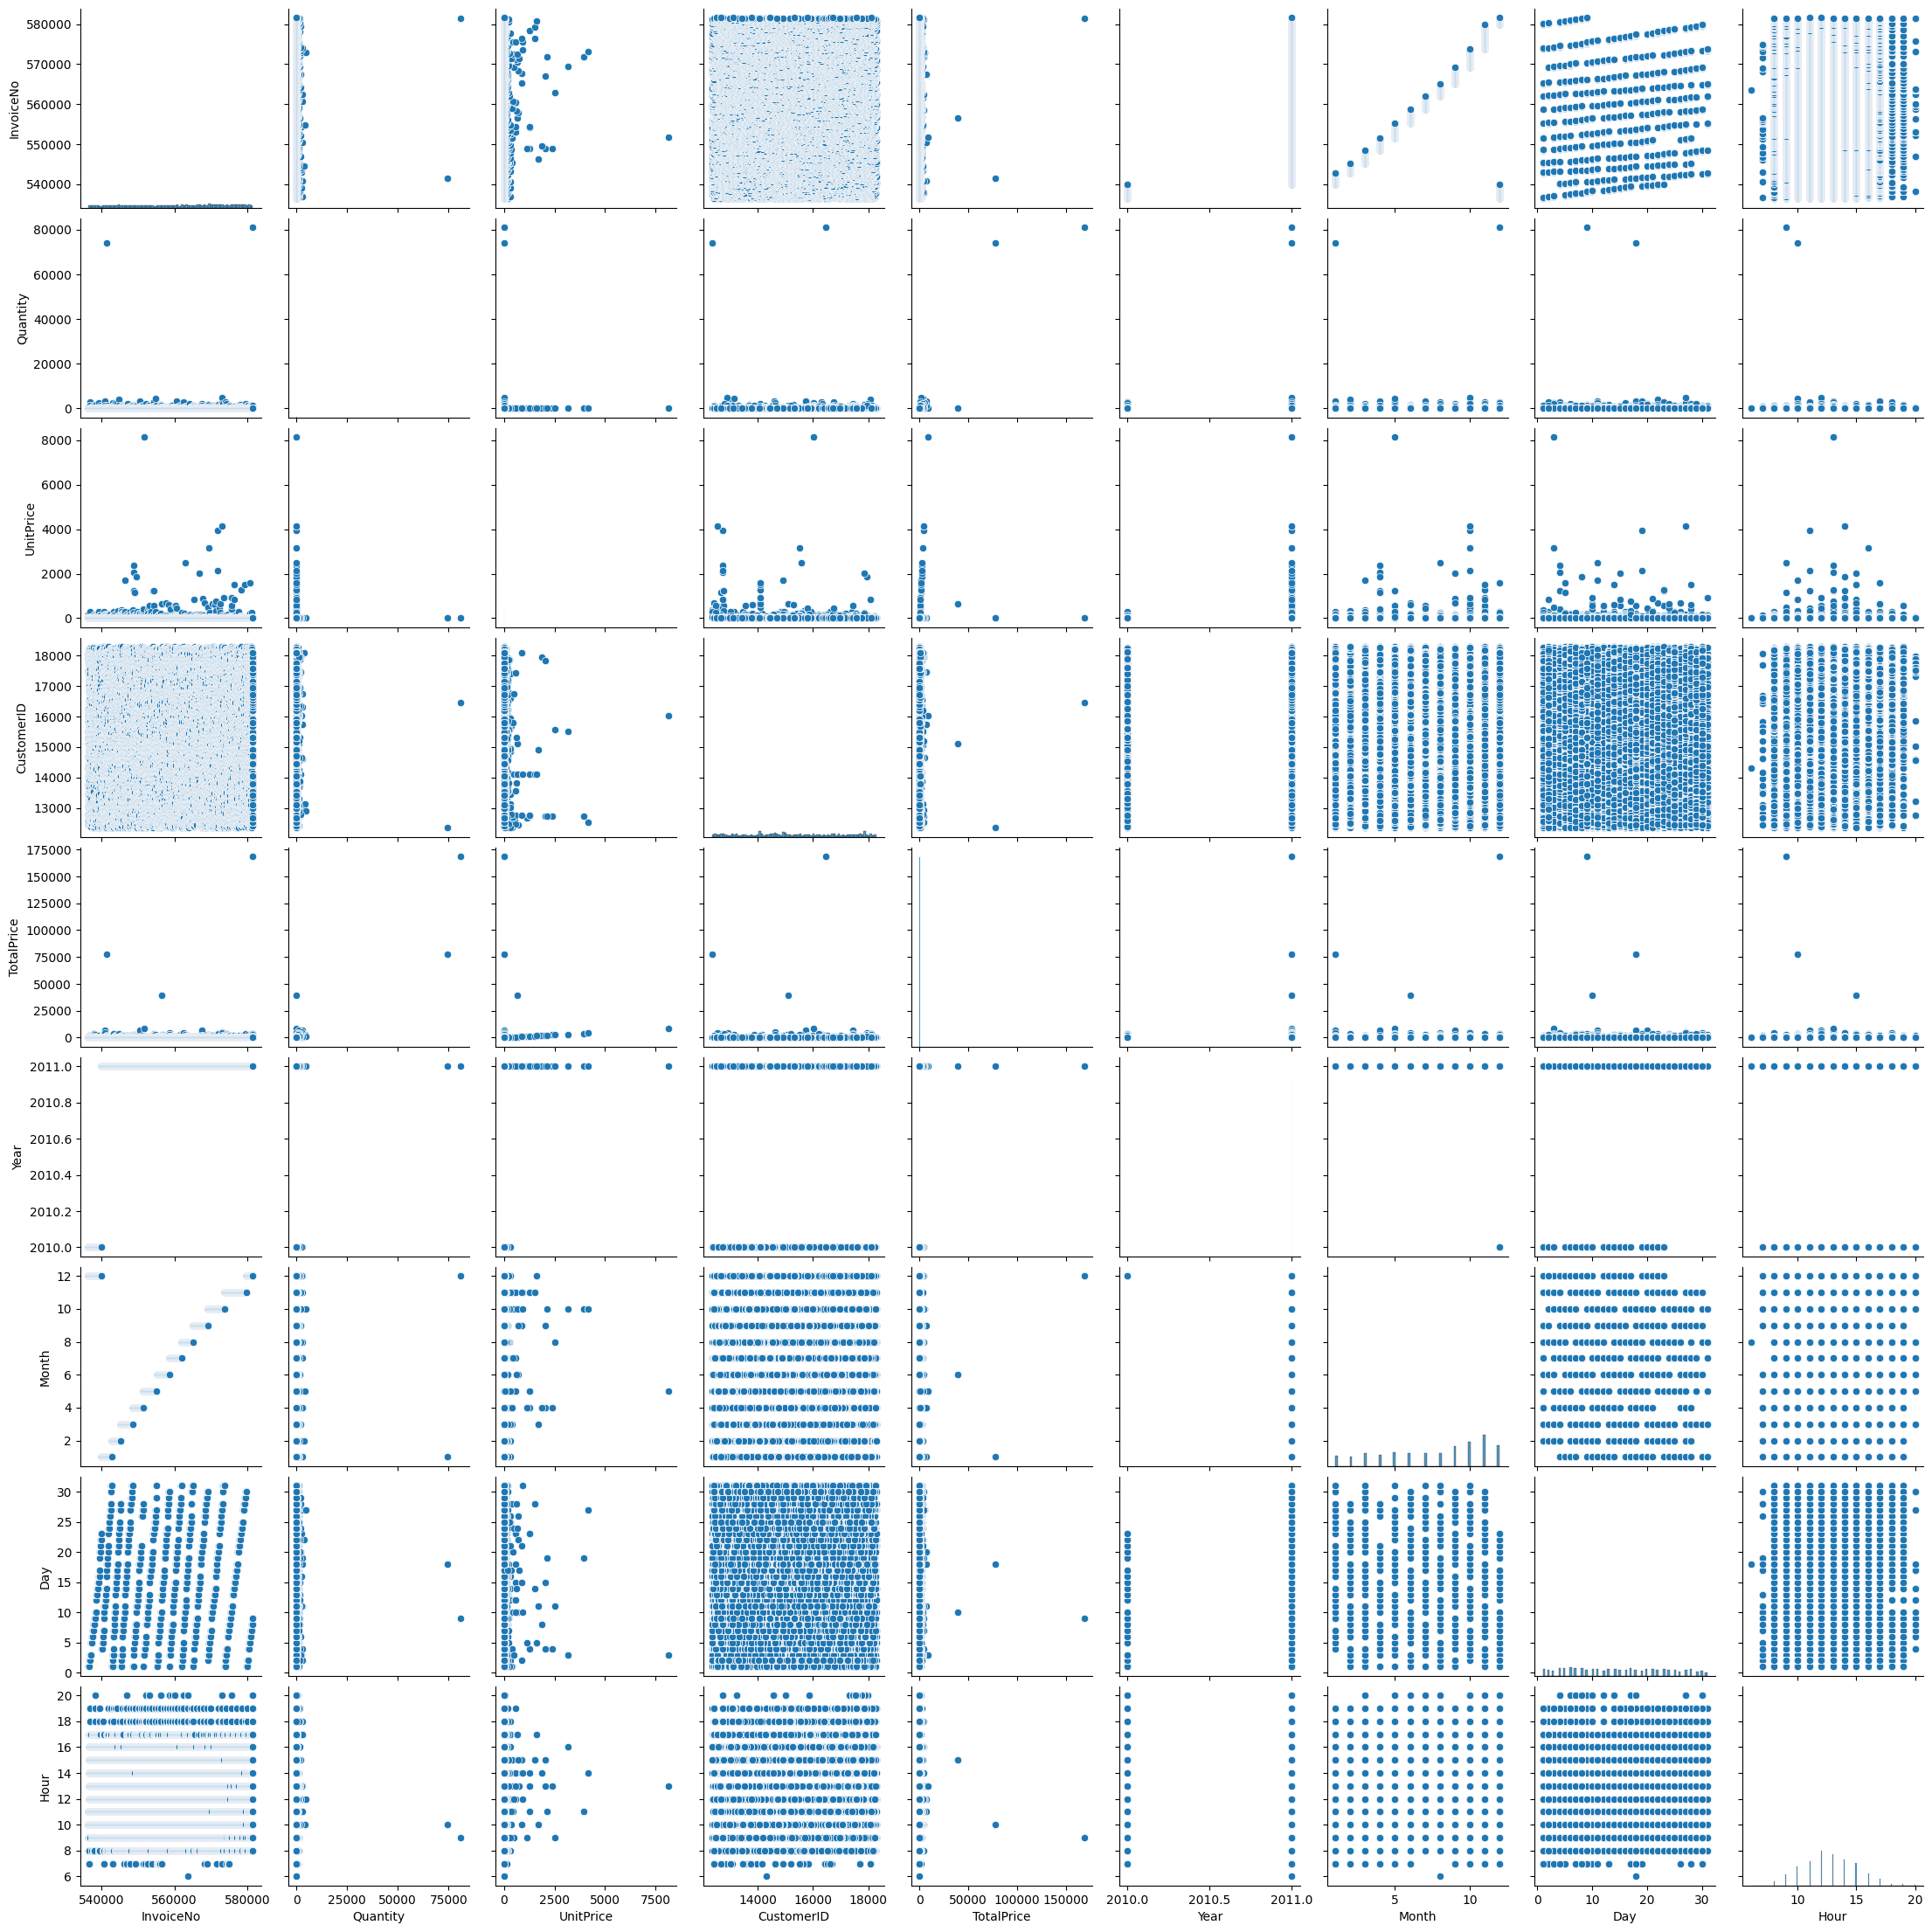

In [46]:
sns.pairplot(data=df)
plt.show()

In [47]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,Hour,Customer_segment,Order_Type,Day_Type
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,8,Verylow,Small,Weekday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Verylow,Small,Weekday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,8,Verylow,Small,Weekday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Verylow,Small,Weekday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Verylow,Small,Weekday
